Cost and Burden Analysis

1. Using data from Cory (Data\raw\oil_prices_20260603_112515.parquet)

In [37]:
import sys

sys.path.insert(0, 'Data\raw')
sys.path.insert(0, 'Data_loaders')

In [38]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


In [39]:
import os
print("Current Working Directory:", os.getcwd())

print("Local Folder Contents:", os.listdir("."))

Current Working Directory: c:\Users\eye24\OneDrive\ドキュメント\GitHub\AI-Immigration\Visualisation_Board
Local Folder Contents: ['Bypass_Pipeline_Capacity_(Aston).ipynb', 'Change_in_Malacca_Volumes_(Akylai).ipynb', 'Cost-Burden_Analysis_(Ai & Ririka).ipynb', 'Impacts_on_Global_Oil_Trade_(Mami).ipynb', 'Visualisation_Board']


In [40]:
pip install pandas pyarrow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"..\Data\raw\oil_prices_20260603_112515.parquet"
df = pd.read_parquet(file_path)
print(df.head())
print(df.info())

        date                                             region  price_usd_bbl
0 1960-01-31  Crude oil price (USD/bbl) - World average - Wo...           1.63
1 1960-01-31  Crude oil price (USD/bbl) - Asia - World Bank ...           1.63
2 1960-01-31  Crude oil price (USD/bbl) - Europe - World Ban...           1.63
3 1960-02-29  Crude oil price (USD/bbl) - Europe - World Ban...           1.63
4 1960-02-29  Crude oil price (USD/bbl) - Asia - World Bank ...           1.63
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2920 non-null   datetime64[us]
 1   region         2920 non-null   object        
 2   price_usd_bbl  2920 non-null   float64       
dtypes: datetime64[us](1), float64(1), object(1)
memory usage: 68.6+ KB
None


In [42]:
date_col = None
for col in df.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        date_col = col
    break
            
if date_col:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.sort_values(by=date_col)
        df.set_index(date_col, inplace=True)


In [43]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"{numeric_cols}")

['price_usd_bbl']


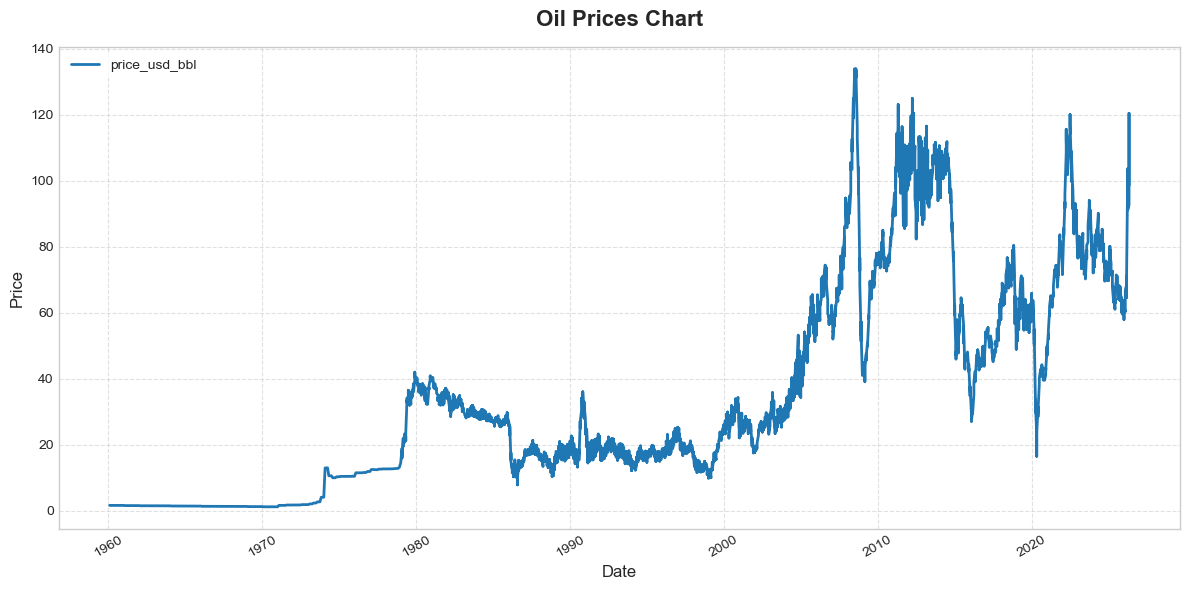

In [44]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 6))
        
for col in numeric_cols:
    ax.plot(df.index, df[col], label=col, linewidth=2)
        
ax.set_title('Oil Prices Chart', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date' if date_col else 'Index', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
        
plt.xticks(rotation=30)
plt.tight_layout()